# MLOps Exercise — Python 3.12 Compatible Version
This notebook replaces **PyCaret** with **scikit-learn + MLflow**, so it runs on **Python 3.12**.

In [1]:
!pip install -q scikit-learn mlflow pandas matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.2 MB/s eta 0:00:00


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso


In [4]:
!wget -q -nc https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv -O diamond.csv
dataset = pd.read_csv("diamond.csv")
dataset.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
print("Shape:", dataset.shape)
print(dataset.columns.tolist())
print(dataset.isnull().sum())

Shape: (53940, 10)
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [6]:
data = dataset.sample(frac=0.9, random_state=786).reset_index(drop=True)
data_unseen = dataset.drop(data.index).reset_index(drop=True)
print(data.shape, data_unseen.shape)

(48546, 10) (5394, 10)


In [8]:
target='price'
X=data.drop(columns=[target]); y=data[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=123)
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
preprocessor = ColumnTransformer(transformers=[('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), numeric_features)])
print(numeric_features)

['carat', 'depth', 'table', 'x', 'y', 'z']


In [9]:
mlflow.set_experiment("diamond")

2026/04/07 07:26:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/07 07:26:00 INFO mlflow.store.db.utils: Updating database tables
2026/04/07 07:26:03 INFO mlflow.tracking.fluent: Experiment with name 'diamond' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1775546763819, experiment_id='1', last_update_time=1775546763819, lifecycle_stage='active', name='diamond', tags={}, workspace='default'>

In [10]:
models={"Linear Regression":LinearRegression(),"Ridge":Ridge(),"Lasso":Lasso(),"Random Forest":RandomForestRegressor(random_state=123),"Extra Trees":ExtraTreesRegressor(random_state=123),"Gradient Boosting":GradientBoostingRegressor(random_state=123)}
results=[]
for name, model in models.items():
    pipe=Pipeline(steps=[('preprocessor', preprocessor),('model', model)])
    scores=cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    results.append({'Model':name,'Mean R2':scores.mean(),'Std R2':scores.std()})
results_df=pd.DataFrame(results).sort_values(by='Mean R2', ascending=False)
results_df

,Model,Mean R2,Std R2
5,Gradient Boosting,0.884558,0.001505
3,Random Forest,0.877536,0.001442
4,Extra Trees,0.873869,0.001652
2,Lasso,0.857535,0.006204
1,Ridge,0.857330,0.006571
0,Linear Regression,0.857325,0.006600


In [12]:
et_pipeline=Pipeline(steps=[('preprocessor', preprocessor),('model', ExtraTreesRegressor(random_state=123))])
et_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carat', 'depth', 'table',
                                                   'x', 'y', 'z'])])),
                ('model', ExtraTreesRegressor(random_state=123))])

In [13]:
param_dist={'model__n_estimators':[100,200,300],'model__max_depth':[None,10,20,30],'model__min_samples_split':[2,5,10],'model__min_samples_leaf':[1,2,4]}
random_search=RandomizedSearchCV(estimator=et_pipeline,param_distributions=param_dist,n_iter=10,cv=5,scoring='r2',random_state=123,n_jobs=-1)
random_search.fit(X_train, y_train)
tuned_et=random_search.best_estimator_
print(random_search.best_params_, random_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 20} 0.885985559443576


In [14]:
y_pred=tuned_et.predict(X_test)
mae=mean_absolute_error(y_test,y_pred); mse=mean_squared_error(y_test,y_pred); rmse=np.sqrt(mse); r2=r2_score(y_test,y_pred)
print(mae,mse,rmse,r2)

763.9364557202836 1836965.492606159 1355.3470008105521 0.8849810539505999


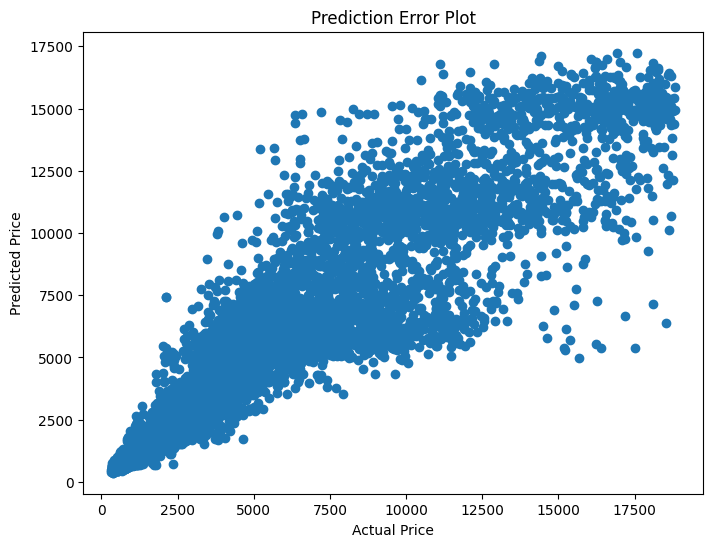

In [15]:
plt.figure(figsize=(8,6)); plt.scatter(y_test,y_pred); plt.xlabel('Actual Price'); plt.ylabel('Predicted Price'); plt.title('Prediction Error Plot'); plt.show()

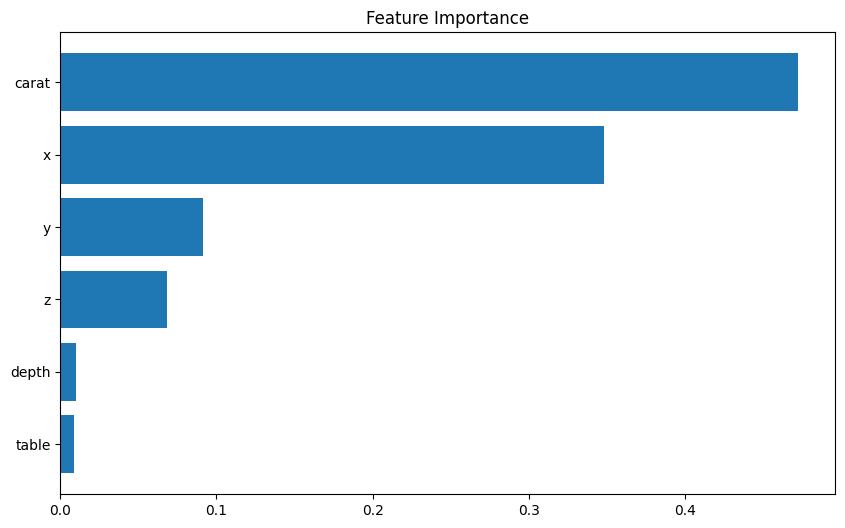

,Feature,Importance
0,carat,0.472619
3,x,0.348182
4,y,0.091307
5,z,0.068555
1,depth,0.010269
2,table,0.009068


In [16]:
model=tuned_et.named_steps['model']
feature_df=pd.DataFrame({'Feature':numeric_features,'Importance':model.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6)); plt.barh(feature_df['Feature'], feature_df['Importance']); plt.gca().invert_yaxis(); plt.title('Feature Importance'); plt.show(); feature_df.head(10)

In [17]:
X_full=data.drop(columns=[target]); y_full=data[target]
final_et=random_search.best_estimator_
final_et.fit(X_full,y_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carat', 'depth', 'table',
                                                   'x', 'y', 'z'])])),
                ('model',
                 ExtraTreesRegressor(max_depth=20, min_samples_split=10,
                                     n_estimators=300, random_state=123))])

In [18]:
X_unseen=data_unseen.drop(columns=[target], errors='ignore')
unseen_predictions=data_unseen.copy(); unseen_predictions['Prediction']=final_et.predict(X_unseen)
unseen_predictions.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,Prediction
0,0.61,Very Good,F,VS2,61.8,56.0,1989,5.42,5.46,3.36,2325.780473
1,0.72,Very Good,J,SI1,63.0,58.0,1989,5.67,5.70,3.58,2583.569555
2,0.74,Good,H,VS2,59.2,64.0,1989,5.79,5.66,3.40,2075.043010
3,0.65,Ideal,E,SI1,62.7,54.0,1989,5.58,5.56,3.49,1936.953686
4,0.54,Premium,F,VS2,62.0,59.0,1989,5.22,5.16,3.22,1615.784046


In [19]:
with mlflow.start_run(run_name='ExtraTrees_Diamond_Model'):
    mlflow.log_param('model','ExtraTreesRegressor')
    mlflow.log_param('random_state',123)
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric('MAE',mae); mlflow.log_metric('MSE',mse); mlflow.log_metric('RMSE',rmse); mlflow.log_metric('R2',r2)
    mlflow.sklearn.log_model(final_et, 'finalized_model')
print('Model logged to MLflow successfully.')

2026/04/07 09:11:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 09:11:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow successfully.
